In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# CONFIGURATION — edit these to match your paths
# ============================================================

FILES_LIST   = 'configs/files_to_process_analysis.txt'
TREE_NAME    = 'XSecAnalyzer/NuMICC1eNp'
ENERGY_BRANCH = 'reco_electron_energy'
BRANCH_CATEGORY = 'NuMICC1eNp_Cats'

BINS   = np.array([0.02, 0.42, 0.62, 0.82, 1.22, 2.5])
XLOW   = BINS[0]
XHIGH  = BINS[-1]
BOGUS  = -9999.0

X_LABEL   = 'Electron Energy [GeV]'
X_TICKS   = [0.02, 0.42, 0.62, 0.82, 1.22]
Y_LABEL   = 'Events (Unweighted)'
RUN_LABEL = 'MicroBooNE Run 4b RHC'

# ============================================================
# CATEGORY DEFINITIONS — colours and labels match top.py
# ============================================================

# (C++ category string, latex label, colour)
CATEGORIES = [
    ('#nu_{e} CC0#piNp',       r'$\nu_e$ CC0$\pi$Np',                'orange'   ),
    ('#bar{#nu}_{e} CC0#piNp', r'$\bar{\nu}_e$ CC0$\pi$Np',          'gold'     ),
    ('#nu_{e} CC Other',       r'$\nu_e$ CC other',                   '#05B415'  ),
    ('#bar{#nu}_{e} CC Other', r'$\bar{\nu}_e$ CC other',             '#33db09'  ),
    ('#nu_{#mu} CC Other',     r'$\nu_\mu$ CC',                       '#437ED8'  ),
    ('#nu_{#mu} CC #pi^{0}',   r'$\nu_\mu$ CC $\pi^0$',              'brown'    ),
    ('NC #pi^{0}',             r'NC $\pi^0$',                         'orangered'),
    ('NC Other',               r'NC other',                           '#33FCFF'  ),
    ('Out FV',                 r'Out FV',                             'orchid'   ),
    ('Unknown',                r'EXT',                                'lightpink'),
]

# ============================================================
# FILE LIST PARSER
# ============================================================

def parse_file_list(filepath):
    entries = []
    with open(filepath, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            entries.append((parts[0], parts[1], parts[2]))
    return entries

entries = parse_file_list(FILES_LIST)
print(f'Found {len(entries)} files:')
for path, ft, bm in entries:
    print(f'  [{ft}] {path}')


Found 4 files:
  [nueMC] /exp/uboone/data/users/abarnard/analysis/selection_output/xsec-ana-checkout_MCC9.10_Run4b_NuMI_RHC_nue_overlay_surprise_v10_04_07_09_reco2_hist_bdt_weighted.root
  [numuMC] /exp/uboone/data/users/abarnard/analysis/selection_output/xsec-ana-checkout_MCC9.10_Run4b_v10_04_07_20_NuMI_RHC_nu_overlay_patch_retuple_retuple_hist_bdt_weighted.root
  [extBNB] /exp/uboone/data/users/abarnard/analysis/selection_output/xsec-ana-checkout_MCC9.10_Run4b_NuMI_beam_off_RHC_data_surprise_v10_04_07_09_reco2_hist_bdt_weighted.root
  [dirtMC] /exp/uboone/data/users/abarnard/analysis/selection_output/xsec-ana-checkout_MCC9.10_Run4a4c_NuMI_RHC_dirt_overlay_surprise_reco2_hist_4b_bdt_weighted.root


In [2]:
# ============================================================
# RESOLUTION STUDY HELPERS
# ============================================================

def compute_resolution(entries, prefer,
                       reco_branch_pandora, reco_branch_wirecell,
                       true_branch,
                       pandora_sel_branch='pandora_sel_nue_cc',
                       wc_sel_branch='wc_sel_nue_cc',
                       signal_branch='is_true_signal',
                       fractional=True):
    """
    Compute resolution for union-selected signal events.
    For overlap events, use whichever reconstruction is preferred.
    fractional=True:  (reco - true) / true   (for energies)
    fractional=False: reco - true             (for cos angle)
    """
    reco_vals = []
    true_vals = []

    for root_path, file_type, beam_mode in entries:
        if file_type == 'extBNB':
            continue
        try:
            with uproot.open(root_path) as f:
                tree = f[TREE_NAME]

                pandora_sel = tree[pandora_sel_branch].array(library='np').astype(bool)
                wc_sel      = tree[wc_sel_branch].array(library='np').astype(bool)
                is_signal   = tree[signal_branch].array(library='np').astype(bool)
                reco_p      = tree[reco_branch_pandora].array(library='np').astype(float)
                reco_w      = tree[reco_branch_wirecell].array(library='np').astype(float)
                true        = tree[true_branch].array(library='np').astype(float)

                for i in range(len(is_signal)):
                    if not is_signal[i]:
                        continue
                    p_sel = pandora_sel[i]
                    w_sel = wc_sel[i]
                    if not (p_sel or w_sel):
                        continue

                    # Choose reco value based on selection and preference
                    if p_sel and w_sel:
                        reco = reco_p[i] if prefer == 'pandora' else reco_w[i]
                    elif p_sel:
                        reco = reco_p[i]
                    else:
                        reco = reco_w[i]

                    t = true[i]
                    if reco == BOGUS or t == BOGUS or np.isnan(reco) or np.isnan(t):
                        continue
                    if fractional and t == 0:
                        continue

                    reco_vals.append(reco)
                    true_vals.append(t)

        except Exception as e:
            print(f'WARNING: {root_path}: {e}')

    reco_arr = np.array(reco_vals)
    true_arr = np.array(true_vals)

    if fractional:
        return (reco_arr - true_arr) / true_arr
    else:
        return reco_arr - true_arr


def compute_overlap_resolution(entries,
                               reco_branch_pandora, reco_branch_wirecell,
                               true_branch,
                               pandora_sel_branch='pandora_sel_nue_cc',
                               wc_sel_branch='wc_sel_nue_cc',
                               signal_branch='is_true_signal',
                               fractional=True):
    """
    Compute resolution for overlap events only (true signal selected by
    BOTH Pandora AND WireCell). Returns (res_pandora, res_wirecell) over
    the identical event set, so the comparison is purely reconstruction quality.
    """
    res_p_vals = []
    res_w_vals = []

    for root_path, file_type, beam_mode in entries:
        if file_type == 'extBNB':
            continue
        try:
            with uproot.open(root_path) as f:
                tree = f[TREE_NAME]

                pandora_sel = tree[pandora_sel_branch].array(library='np').astype(bool)
                wc_sel      = tree[wc_sel_branch].array(library='np').astype(bool)
                is_signal   = tree[signal_branch].array(library='np').astype(bool)
                reco_p      = tree[reco_branch_pandora].array(library='np').astype(float)
                reco_w      = tree[reco_branch_wirecell].array(library='np').astype(float)
                true        = tree[true_branch].array(library='np').astype(float)

                for i in range(len(is_signal)):
                    if not (is_signal[i] and pandora_sel[i] and wc_sel[i]):
                        continue

                    rp = reco_p[i]
                    rw = reco_w[i]
                    t  = true[i]

                    if (rp == BOGUS or rw == BOGUS or t == BOGUS
                            or np.isnan(rp) or np.isnan(rw) or np.isnan(t)):
                        continue
                    if fractional and t == 0:
                        continue

                    if fractional:
                        res_p_vals.append((rp - t) / t)
                        res_w_vals.append((rw - t) / t)
                    else:
                        res_p_vals.append(rp - t)
                        res_w_vals.append(rw - t)

        except Exception as e:
            print(f'WARNING: {root_path}: {e}')

    return np.array(res_p_vals), np.array(res_w_vals)


def plot_resolution(res_pandora, res_wirecell,
                    xlabel, title, savename,
                    xrange=(-1, 1), nbins=50,
                    run_label='MicroBooNE Run 4b RHC',
                    ymax=None):

    mean_p = res_pandora.mean()
    mean_w = res_wirecell.mean()

    # Central 68% half-width — robust to outliers (postdoc suggestion)
    std68_p = (np.percentile(res_pandora,  84) - np.percentile(res_pandora,  16)) / 2.0
    std68_w = (np.percentile(res_wirecell, 84) - np.percentile(res_wirecell, 16)) / 2.0

    plt.figure(figsize=(7, 4))
    plt.hist(res_pandora,  bins=nbins, range=xrange,
             label=fr'$\mathtt{{Pandora}}$ ($\mu$={mean_p:.3f}, $\sigma_{{68}}$={std68_p:.3f})',
             color='C0', density=True, histtype='step', linewidth=2)
    plt.hist(res_wirecell, bins=nbins, range=xrange,
             label=fr'$\mathtt{{WireCell}}$ ($\mu$={mean_w:.3f}, $\sigma_{{68}}$={std68_w:.3f})',
             color='C1', density=True, histtype='step', linewidth=2)
    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel('Normalized Events', fontsize=14)
    plt.title(title, fontsize=15)
    plt.text(0.03, 0.93, run_label, transform=plt.gca().transAxes,
             ha='left', va='top', fontsize=11,
             bbox=dict(facecolor='white', alpha=0, edgecolor='none', pad=3))
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tick_params(axis='both', labelsize=13)
    plt.xlim(*xrange)
    plt.axvline(0, color='k', linestyle='dashed', linewidth=1)
    if ymax:
        plt.ylim(0, ymax)
    plt.savefig(savename, transparent=False, bbox_inches='tight', dpi=300)
    plt.show()

    print(f'Pandora prefer:  mean = {mean_p:.3f}, std68 = {std68_p:.3f}')
    print(f'WireCell prefer: mean = {mean_w:.3f}, std68 = {std68_w:.3f}')

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


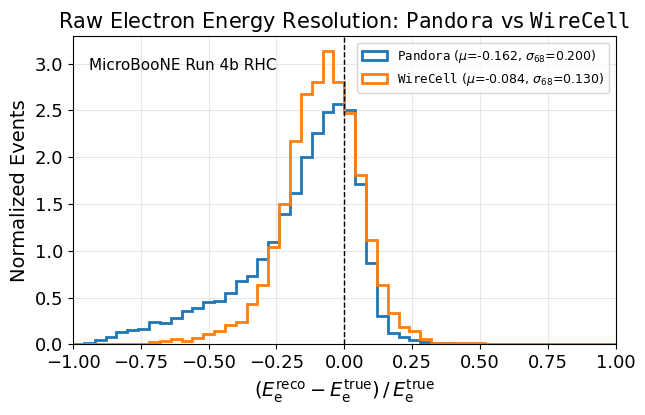

Pandora prefer:  mean = -0.162, std68 = 0.200
WireCell prefer: mean = -0.084, std68 = 0.130


In [3]:
# ============================================================
# RAW RESOLUTION (per-selection, not unified)
# Matches compute_raw_resolution() in selection.ipynb
# ============================================================

def compute_raw_resolution(entries, reco_branch, true_branch,
                           sel_branch, fractional=True):
    """
    Compute raw resolution for events passing a single selection,
    restricted to true signal only. Mirrors compute_raw_resolution()
    in selection.ipynb.
    """
    reco_vals = []
    true_vals = []

    for root_path, file_type, beam_mode in entries:
        if file_type == 'extBNB':
            continue
        try:
            with uproot.open(root_path) as f:
                tree = f[TREE_NAME]

                sel       = tree[sel_branch].array(library='np').astype(bool)
                is_signal = tree['is_true_signal'].array(library='np').astype(bool)
                reco      = tree[reco_branch].array(library='np').astype(float)
                true      = tree[true_branch].array(library='np').astype(float)

                mask = sel & is_signal
                reco_sel = reco[mask]
                true_sel = true[mask]

                for r, t in zip(reco_sel, true_sel):
                    if r == BOGUS or t == BOGUS or np.isnan(r) or np.isnan(t):
                        continue
                    if fractional and t == 0:
                        continue
                    reco_vals.append(r)
                    true_vals.append(t)

        except Exception as e:
            print(f'WARNING: {root_path}: {e}')

    reco_arr = np.array(reco_vals)
    true_arr = np.array(true_vals)

    if fractional:
        return (reco_arr - true_arr) / true_arr
    else:
        return reco_arr - true_arr


# --- Electron energy raw resolution ---
res_e_pandora_raw  = compute_raw_resolution(entries,
    reco_branch='pandora_reco_electron_energy',
    true_branch='true_elec_e',
    sel_branch='pandora_sel_nue_cc', fractional=True)

res_e_wirecell_raw = compute_raw_resolution(entries,
    reco_branch='wc_reco_electron_energy',
    true_branch='true_elec_e',
    sel_branch='wc_sel_nue_cc', fractional=True)

plot_resolution(res_e_pandora_raw, res_e_wirecell_raw,
    xlabel=r'$(E^\mathrm{reco}_{\mathrm{e}} - E^\mathrm{true}_{\mathrm{e}})\,/\,E^\mathrm{true}_{\mathrm{e}}$',
    title=r'Raw Electron Energy Resolution: $\mathtt{Pandora}$ vs $\mathtt{WireCell}$',
    savename='electron_energy_raw_resolution.pdf',
    xrange=(-1, 1), nbins=50)

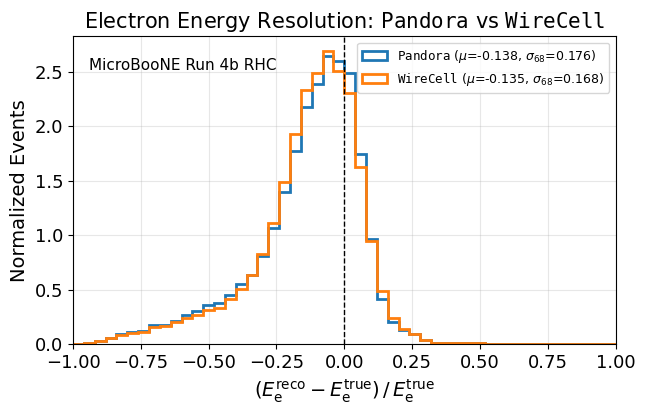

Pandora prefer:  mean = -0.138, std68 = 0.176
WireCell prefer: mean = -0.135, std68 = 0.168


In [4]:
# ============================================================
# ELECTRON ENERGY RESOLUTION
# ============================================================

res_e_pandora = compute_resolution(entries, prefer='pandora',
    reco_branch_pandora='pandora_reco_electron_energy',
    reco_branch_wirecell='wc_reco_electron_energy',
    true_branch='true_elec_e', fractional=True)

res_e_wirecell = compute_resolution(entries, prefer='wirecell',
    reco_branch_pandora='pandora_reco_electron_energy',
    reco_branch_wirecell='wc_reco_electron_energy',
    true_branch='true_elec_e', fractional=True)

plot_resolution(res_e_pandora, res_e_wirecell,
    xlabel=r'$(E^\mathrm{reco}_{\mathrm{e}} - E^\mathrm{true}_{\mathrm{e}})\,/\,E^\mathrm{true}_{\mathrm{e}}$',
    title=r'Electron Energy Resolution: $\mathtt{Pandora}$ vs $\mathtt{WireCell}$',
    savename='electron_energy_resolution.pdf',
    xrange=(-1, 1), nbins=50)

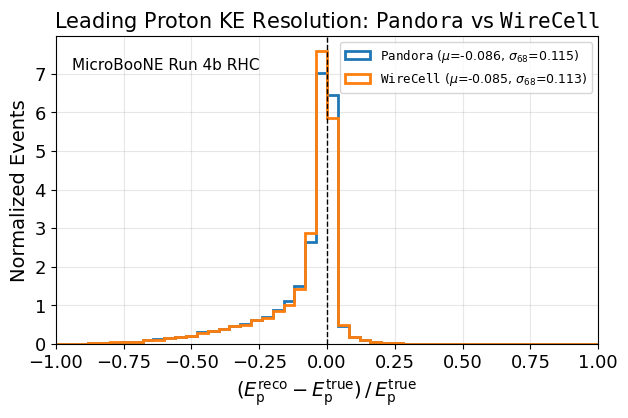

Pandora prefer:  mean = -0.086, std68 = 0.115
WireCell prefer: mean = -0.085, std68 = 0.113


In [5]:
# ============================================================
# LEADING PROTON KE RESOLUTION
# ============================================================

res_p_pandora = compute_resolution(entries, prefer='pandora',
    reco_branch_pandora='pandora_reco_track_energy',
    reco_branch_wirecell='wc_reco_track_energy',
    true_branch='true_proton_ke', fractional=True)

res_p_wirecell = compute_resolution(entries, prefer='wirecell',
    reco_branch_pandora='pandora_reco_track_energy',
    reco_branch_wirecell='wc_reco_track_energy',
    true_branch='true_proton_ke', fractional=True)

plot_resolution(res_p_pandora, res_p_wirecell,
    xlabel=r'$(E^\mathrm{reco}_{\mathrm{p}} - E^\mathrm{true}_{\mathrm{p}})\,/\,E^\mathrm{true}_{\mathrm{p}}$',
    title=r'Leading Proton KE Resolution: $\mathtt{Pandora}$ vs $\mathtt{WireCell}$',
    savename='proton_ke_resolution.pdf',
    xrange=(-1, 1), nbins=50)

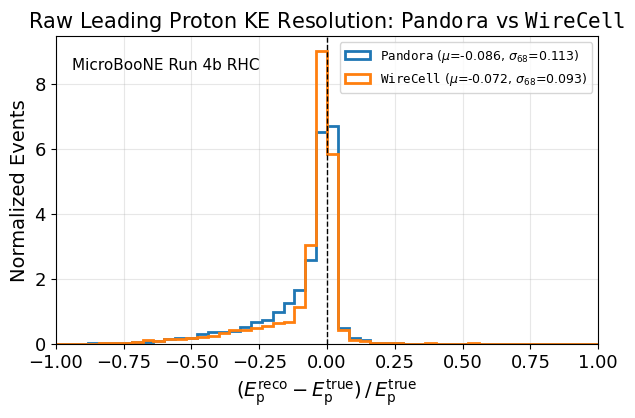

Pandora prefer:  mean = -0.086, std68 = 0.113
WireCell prefer: mean = -0.072, std68 = 0.093


In [6]:
# --- Leading proton KE raw resolution ---
res_p_pandora_raw  = compute_raw_resolution(entries,
    reco_branch='pandora_reco_track_energy',
    true_branch='true_proton_ke',
    sel_branch='pandora_sel_nue_cc', fractional=True)

res_p_wirecell_raw = compute_raw_resolution(entries,
    reco_branch='wc_reco_track_energy',
    true_branch='true_proton_ke',
    sel_branch='wc_sel_nue_cc', fractional=True)

plot_resolution(res_p_pandora_raw, res_p_wirecell_raw,
    xlabel=r'$(E^\mathrm{reco}_{\mathrm{p}} - E^\mathrm{true}_{\mathrm{p}})\,/\,E^\mathrm{true}_{\mathrm{p}}$',
    title=r'Raw Leading Proton KE Resolution: $\mathtt{Pandora}$ vs $\mathtt{WireCell}$',
    savename='proton_ke_raw_resolution.pdf',
    xrange=(-1, 1), nbins=50)

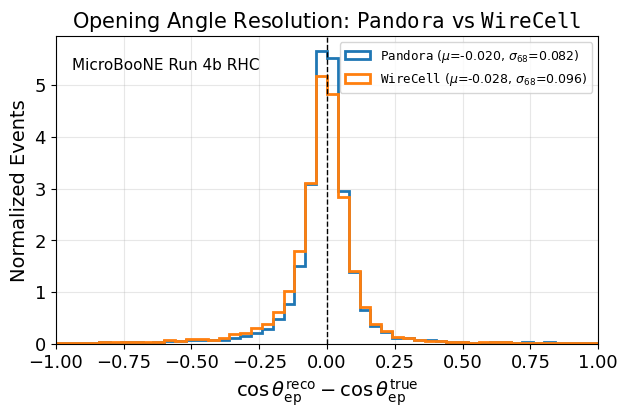

Pandora prefer:  mean = -0.020, std68 = 0.082
WireCell prefer: mean = -0.028, std68 = 0.096


In [7]:
# ============================================================
# OPENING ANGLE RESOLUTION
# Absolute difference used (not fractional) since cos(angle)
# can be ~0 and fractional resolution would diverge
# ============================================================

res_a_pandora = compute_resolution(entries, prefer='pandora',
    reco_branch_pandora='pandora_reco_opening_angle',
    reco_branch_wirecell='wc_reco_opening_angle',
    true_branch='true_cos_opening_angle', fractional=False)

res_a_wirecell = compute_resolution(entries, prefer='wirecell',
    reco_branch_pandora='pandora_reco_opening_angle',
    reco_branch_wirecell='wc_reco_opening_angle',
    true_branch='true_cos_opening_angle', fractional=False)

plot_resolution(res_a_pandora, res_a_wirecell,
    xlabel=r'$\cos\theta_{\mathrm{ep}}^\mathrm{reco} - \cos\theta_{\mathrm{ep}}^\mathrm{true}$',
    title=r'Opening Angle Resolution: $\mathtt{Pandora}$ vs $\mathtt{WireCell}$',
    savename='opening_angle_resolution.pdf',
    xrange=(-1, 1), nbins=50)

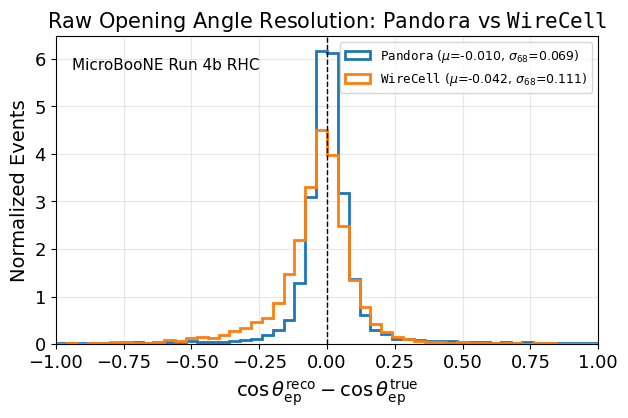

Pandora prefer:  mean = -0.010, std68 = 0.069
WireCell prefer: mean = -0.042, std68 = 0.111


In [8]:
# --- Opening angle raw resolution ---
res_a_pandora_raw  = compute_raw_resolution(entries,
    reco_branch='pandora_reco_opening_angle',
    true_branch='true_cos_opening_angle',
    sel_branch='pandora_sel_nue_cc', fractional=False)

res_a_wirecell_raw = compute_raw_resolution(entries,
    reco_branch='wc_reco_opening_angle',
    true_branch='true_cos_opening_angle',
    sel_branch='wc_sel_nue_cc', fractional=False)

plot_resolution(res_a_pandora_raw, res_a_wirecell_raw,
    xlabel=r'$\cos\theta_{\mathrm{ep}}^\mathrm{reco} - \cos\theta_{\mathrm{ep}}^\mathrm{true}$',
    title=r'Raw Opening Angle Resolution: $\mathtt{Pandora}$ vs $\mathtt{WireCell}$',
    savename='opening_angle_raw_resolution.pdf',
    xrange=(-1, 1), nbins=50)

Overlap signal events (electron energy): 5408


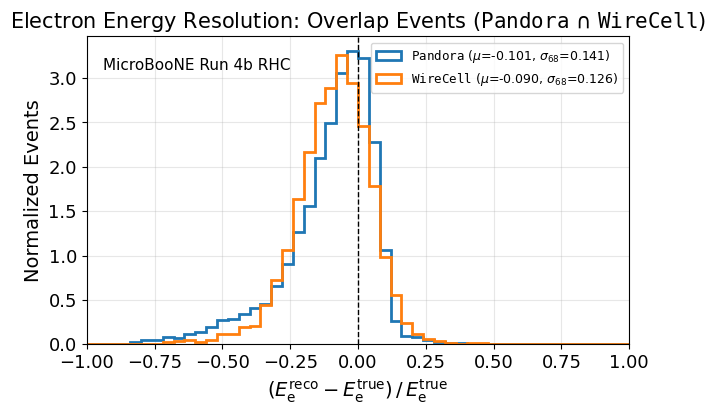

Pandora prefer:  mean = -0.101, std68 = 0.141
WireCell prefer: mean = -0.090, std68 = 0.126


In [9]:
# ============================================================
# OVERLAP ELECTRON ENERGY RESOLUTION
# Events selected by BOTH Pandora AND WireCell (true signal only).
# Both reconstructions are evaluated on the identical event set.
# ============================================================

res_e_overlap_p, res_e_overlap_w = compute_overlap_resolution(entries,
    reco_branch_pandora='pandora_reco_electron_energy',
    reco_branch_wirecell='wc_reco_electron_energy',
    true_branch='true_elec_e', fractional=True)

print(f'Overlap signal events (electron energy): {len(res_e_overlap_p)}')

plot_resolution(res_e_overlap_p, res_e_overlap_w,
    xlabel=r'$(E^\mathrm{reco}_{\mathrm{e}} - E^\mathrm{true}_{\mathrm{e}})\,/\,E^\mathrm{true}_{\mathrm{e}}$',
    title=r'Electron Energy Resolution: Overlap Events ($\mathtt{Pandora}$ $\cap$ $\mathtt{WireCell}$)',
    savename='electron_energy_overlap_resolution.pdf',
    xrange=(-1, 1), nbins=50)

Overlap signal events (proton KE): 5408


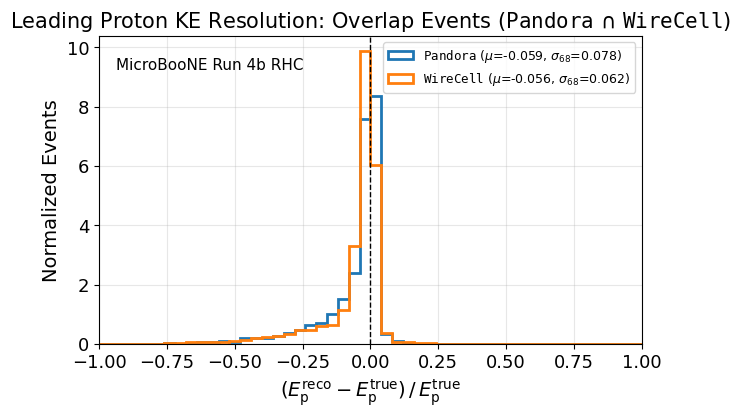

Pandora prefer:  mean = -0.059, std68 = 0.078
WireCell prefer: mean = -0.056, std68 = 0.062


In [10]:
# ============================================================
# OVERLAP LEADING PROTON KE RESOLUTION
# ============================================================

res_p_overlap_p, res_p_overlap_w = compute_overlap_resolution(entries,
    reco_branch_pandora='pandora_reco_track_energy',
    reco_branch_wirecell='wc_reco_track_energy',
    true_branch='true_proton_ke', fractional=True)

print(f'Overlap signal events (proton KE): {len(res_p_overlap_p)}')

plot_resolution(res_p_overlap_p, res_p_overlap_w,
    xlabel=r'$(E^\mathrm{reco}_{\mathrm{p}} - E^\mathrm{true}_{\mathrm{p}})\,/\,E^\mathrm{true}_{\mathrm{p}}$',
    title=r'Leading Proton KE Resolution: Overlap Events ($\mathtt{Pandora}$ $\cap$ $\mathtt{WireCell}$)',
    savename='proton_ke_overlap_resolution.pdf',
    xrange=(-1, 1), nbins=50)

Overlap signal events (opening angle): 5408


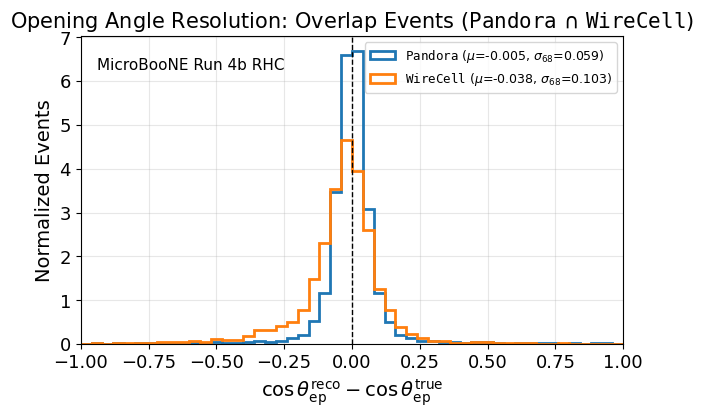

Pandora prefer:  mean = -0.005, std68 = 0.059
WireCell prefer: mean = -0.038, std68 = 0.103


In [11]:
# ============================================================
# OVERLAP OPENING ANGLE RESOLUTION
# ============================================================

res_a_overlap_p, res_a_overlap_w = compute_overlap_resolution(entries,
    reco_branch_pandora='pandora_reco_opening_angle',
    reco_branch_wirecell='wc_reco_opening_angle',
    true_branch='true_cos_opening_angle', fractional=False)

print(f'Overlap signal events (opening angle): {len(res_a_overlap_p)}')

plot_resolution(res_a_overlap_p, res_a_overlap_w,
    xlabel=r'$\cos\theta_{\mathrm{ep}}^\mathrm{reco} - \cos\theta_{\mathrm{ep}}^\mathrm{true}$',
    title=r'Opening Angle Resolution: Overlap Events ($\mathtt{Pandora}$ $\cap$ $\mathtt{WireCell}$)',
    savename='opening_angle_overlap_resolution.pdf',
    xrange=(-1, 1), nbins=50)

In [12]:
# ============================================================
# SHARED: accumulate histogram counts from all files
# ============================================================

def accumulate(entries, sel_branch):
    cat_strings = [c[0] for c in CATEGORIES]
    counts    = {cat: np.zeros(len(BINS) - 1) for cat in cat_strings}
    counts_sq = {cat: np.zeros(len(BINS) - 1) for cat in cat_strings}

    n_signal           = 0
    n_selected_signal  = 0
    n_selected_total   = 0

    for root_path, file_type, beam_mode in entries:
        try:
            with uproot.open(root_path) as f:
                tree = f[TREE_NAME]

                selected = tree[sel_branch].array(library='np').astype(bool)
                energy   = tree[ENERGY_BRANCH].array(library='np')
                category = tree[BRANCH_CATEGORY].array(library='np')

                n_selected_total += selected.sum()

                if file_type != 'extBNB':
                    is_signal = tree['is_true_signal'].array(library='np').astype(bool)
                    n_signal           += is_signal.sum()
                    n_selected_signal  += (selected & is_signal).sum()

                mask = (
                    selected &
                    (energy != BOGUS) &
                    (energy >= XLOW) &
                    (energy < XHIGH)
                )

                energy_sel   = energy[mask]
                category_sel = category[mask]

                if file_type == 'extBNB':
                    h, _ = np.histogram(energy_sel, bins=BINS)
                    counts['Unknown']    += h
                    counts_sq['Unknown'] += h
                    continue

                for cat in cat_strings:
                    cat_mask = (category_sel == cat)
                    h, _ = np.histogram(energy_sel[cat_mask], bins=BINS)
                    counts[cat]    += h
                    counts_sq[cat] += h

        except Exception as e:
            print(f'WARNING: {root_path}: {e}')

    return counts, counts_sq, n_signal, n_selected_signal, n_selected_total


def make_plot(sel_name, counts, counts_sq, n_signal, n_selected_signal, n_selected_total,
              save=True, ymax=None, legend_loc='upper right',
              run_label_pos=(0.03, 0.97), eff_pur_pos=(0.03, 0.87),
              xlabel=None):

    bin_widths  = np.diff(BINS)
    bin_centres = 0.5 * (BINS[:-1] + BINS[1:])

    fig, ax = plt.subplots(figsize=(8, 5))

    # ── legend entries (forward order) ──
    legend_handles = []
    for cat_str, label, color in CATEGORIES:
        c = counts[cat_str]
        if c.sum() == 0:
            continue
        legend_handles.append(
            mpatches.Patch(facecolor=color, label=f'{label}: {int(c.sum())}')
        )

    # ── stacked bars (reversed so signal is on top) ──
    bottom = np.zeros(len(BINS) - 1)
    for cat_str, label, color in reversed(CATEGORIES):
        c = counts[cat_str]
        if c.sum() == 0:
            continue
        ax.bar(
            bin_centres, c,
            width=bin_widths,
            bottom=bottom,
            color=color,
            edgecolor=None,
            linewidth=0,
            align='center',
        )
        bottom += c

    total = bottom.copy()

    # ── stat uncertainty band ──
    total_var = sum(counts_sq[cat] for cat in [c[0] for c in CATEGORIES])
    total_err = np.sqrt(total_var)

    ax.bar(
        bin_centres, 2 * total_err,
        width=bin_widths,
        bottom=total - total_err,
        color='none',
        edgecolor='darkgray',
        hatch='.....',
        linewidth=0,
        align='center',
    )

    stat_patch = mpatches.Patch(
        facecolor='none', edgecolor='darkgray',
        hatch='.....', label='MC Stat. Uncertainty',
    )
    legend_handles.append(stat_patch)

    # ── total outline ──
    ax.step(
        np.repeat(BINS, 2)[1:-1],
        np.repeat(total, 2),
        where='mid',
        color='black',
        linewidth=1.2,
    )

    # ── formatting ──
    ax.set_xlabel(xlabel if xlabel is not None else X_LABEL, fontsize=15, labelpad=8)
    ax.set_ylabel(Y_LABEL, fontsize=15, labelpad=8)
    ax.set_xlim(XLOW, XHIGH)
    ax.set_xticks(X_TICKS)
    ax.tick_params(axis='both', labelsize=14)

    if ymax:
        ax.set_ylim(0, ymax)

    ax.text(run_label_pos[0], run_label_pos[1], RUN_LABEL,
            transform=ax.transAxes, fontsize=14, verticalalignment='top')

    ax.legend(
        handles=legend_handles,
        fontsize=10, ncol=2,
        loc=legend_loc, frameon=False,
    )

    plt.tight_layout()

    if save:
        fname = f'electron_energy_{sel_name.lower().replace(" ", "_")}.pdf'
        plt.savefig(fname, transparent=False, bbox_inches='tight', dpi=300)
        print(f'Saved {fname}')

    plt.show()

print('Helper functions defined.')

Helper functions defined.


Total true signal:       59585
Selected true signal:    15627
Total selected:          18504
Efficiency:              26.23%
Purity:                  84.45%
Saved electron_energy_pandora.pdf


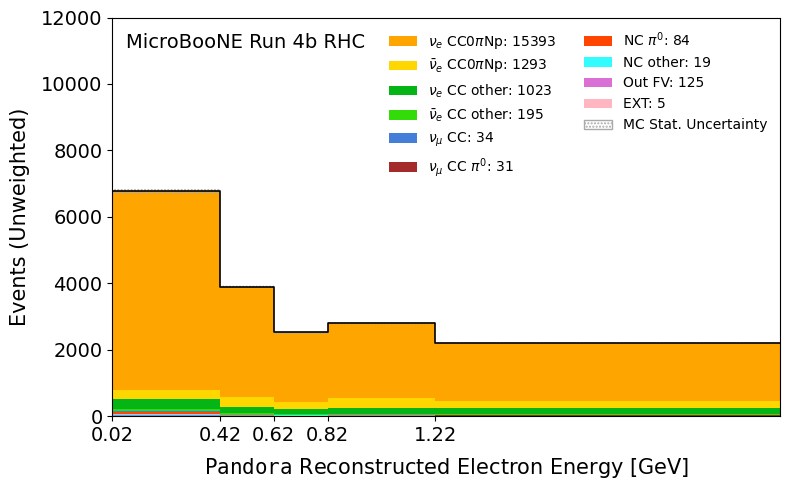

In [13]:
# ============================================================
# PANDORA SELECTION
# ============================================================

pandora_counts, pandora_counts_sq, pandora_n_sig, pandora_n_sel_sig, pandora_n_sel = \
    accumulate(entries, sel_branch='pandora_sel_nue_cc')

print(f'Total true signal:       {pandora_n_sig}')
print(f'Selected true signal:    {pandora_n_sel_sig}')
print(f'Total selected:          {pandora_n_sel}')
if pandora_n_sig > 0 and pandora_n_sel > 0:
    print(f'Efficiency:              {100*pandora_n_sel_sig/pandora_n_sig:.2f}%')
    print(f'Purity:                  {100*pandora_n_sel_sig/pandora_n_sel:.2f}%')

make_plot('Pandora', pandora_counts, pandora_counts_sq,
          pandora_n_sig, pandora_n_sel_sig, pandora_n_sel,
          ymax=12000, legend_loc='upper right',
          run_label_pos=(0.02, 0.96), eff_pur_pos=(0.03, 0.87),
          xlabel=r'$\mathtt{Pandora}$ Reconstructed Electron Energy [GeV]')

Total true signal:       59585
Selected true signal:    11643
Total selected:          13736
Efficiency:              19.54%
Purity:                  84.76%
Saved electron_energy_wirecell.pdf


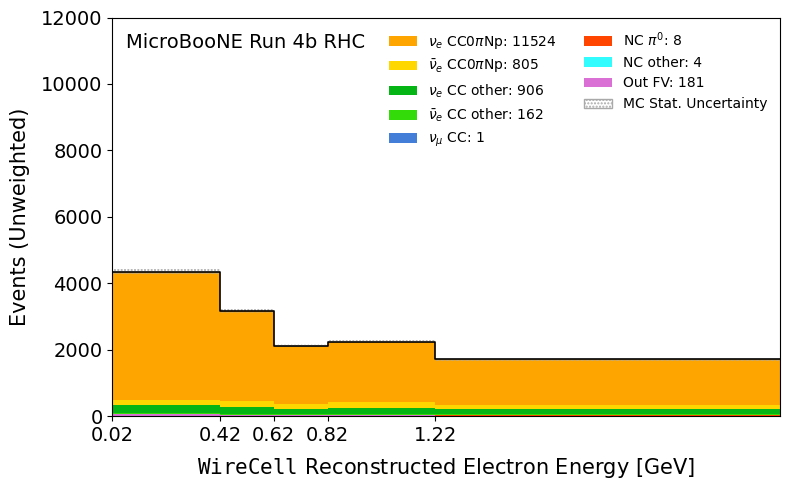

In [14]:
# ============================================================
# WIRECELL SELECTION
# ============================================================

wc_counts, wc_counts_sq, wc_n_sig, wc_n_sel_sig, wc_n_sel = \
    accumulate(entries, sel_branch='wc_sel_nue_cc')

print(f'Total true signal:       {wc_n_sig}')
print(f'Selected true signal:    {wc_n_sel_sig}')
print(f'Total selected:          {wc_n_sel}')
if wc_n_sig > 0 and wc_n_sel > 0:
    print(f'Efficiency:              {100*wc_n_sel_sig/wc_n_sig:.2f}%')
    print(f'Purity:                  {100*wc_n_sel_sig/wc_n_sel:.2f}%')

make_plot('WireCell', wc_counts, wc_counts_sq,
          wc_n_sig, wc_n_sel_sig, wc_n_sel,
          ymax=12000, legend_loc='upper right',
          run_label_pos=(0.02, 0.96), eff_pur_pos=(0.03, 0.87),
          xlabel=r'$\mathtt{WireCell}$ Reconstructed Electron Energy [GeV]')

Total true signal:       59585
Selected true signal:    21862
Total selected:          26303
Efficiency:              36.69%
Purity:                  83.12%
Saved electron_energy_union.pdf


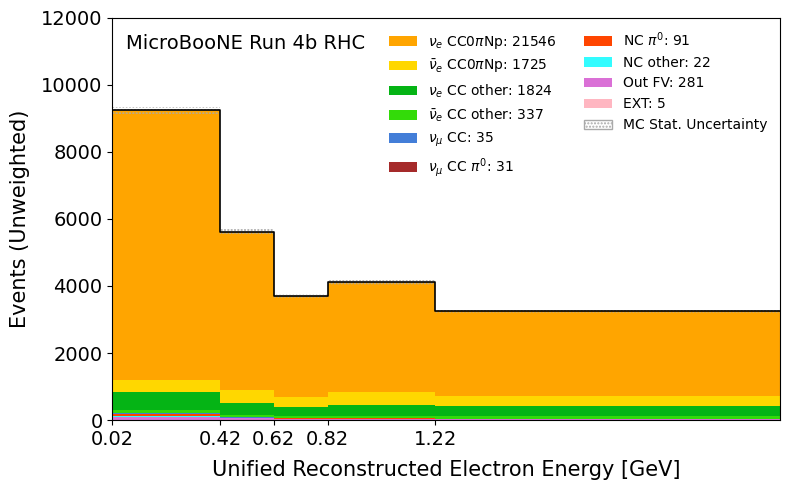

In [15]:
# ============================================================
# UNION SELECTION (Pandora OR WireCell)
# ============================================================

union_counts, union_counts_sq, union_n_sig, union_n_sel_sig, union_n_sel = \
    accumulate(entries, sel_branch='sel_nue_cc')

print(f'Total true signal:       {union_n_sig}')
print(f'Selected true signal:    {union_n_sel_sig}')
print(f'Total selected:          {union_n_sel}')
if union_n_sig > 0 and union_n_sel > 0:
    print(f'Efficiency:              {100*union_n_sel_sig/union_n_sig:.2f}%')
    print(f'Purity:                  {100*union_n_sel_sig/union_n_sel:.2f}%')

make_plot('Union', union_counts, union_counts_sq,
          union_n_sig, union_n_sel_sig, union_n_sel,
          ymax=12000, legend_loc='upper right',
          run_label_pos=(0.02, 0.96), eff_pur_pos=(0.03, 0.87),
          xlabel='Unified Reconstructed Electron Energy [GeV]')

In [16]:
# ============================================================
# SUMMARY TABLE
# ============================================================

print('=' * 60)
print(f'  SELECTION METRICS (unweighted, all files combined)')
print('=' * 60)
print(f'  Total true signal: {pandora_n_sig}')
print()

for name, n_sel_sig, n_sel in [
    ('Pandora',  pandora_n_sel_sig, pandora_n_sel),
    ('WireCell', wc_n_sel_sig,      wc_n_sel),
    ('Union',    union_n_sel_sig,   union_n_sel),
]:
    eff = 100 * n_sel_sig / pandora_n_sig if pandora_n_sig > 0 else 0
    pur = 100 * n_sel_sig / n_sel if n_sel > 0 else 0
    print(f'  {name} selection')
    print(f'    selected true signal: {n_sel_sig}')
    print(f'    total selected:       {n_sel}')
    print(f'    efficiency:           {eff:.2f}%')
    print(f'    purity:               {pur:.2f}%')
    print()

  SELECTION METRICS (unweighted, all files combined)
  Total true signal: 59585

  Pandora selection
    selected true signal: 15627
    total selected:       18504
    efficiency:           26.23%
    purity:               84.45%

  WireCell selection
    selected true signal: 11643
    total selected:       13736
    efficiency:           19.54%
    purity:               84.76%

  Union selection
    selected true signal: 21862
    total selected:       26303
    efficiency:           36.69%
    purity:               83.12%



In [17]:
# ============================================================
# FULL CUTFLOW (unweighted, all files combined)
# ============================================================

pandora_branches = [
    ('pandora_pass_quality',   'Quality + FV'),
    ('pandora_pass_sig',       'Signal definition'),
    ('pandora_pass_pre',       'Preselection (quality AND sig def)'),
    ('pandora_pass_bdt_loose', 'BDT loose cuts'),
    ('pandora_sel_nue_cc',     'BDT score cut (final)'),
]

wc_branches = [
    ('wc_pass_quality', 'Quality + FV'),
    ('wc_pass_sig',     'Signal definition'),
    ('wc_pass_pre',     'Preselection (quality AND sig def)'),
    ('wc_sel_nue_cc',   'BDT score cut (final)'),
]

union_branches = [
    ('sel_nue_cc',             'Final (Pandora OR WireCell)'),
    ('sel_nue_cc_intersection','Intersection (Pandora AND WireCell)'),
]

pandora_counts_cf = {b: 0 for b, _ in pandora_branches}
wc_counts_cf      = {b: 0 for b, _ in wc_branches}
union_counts_cf   = {b: 0 for b, _ in union_branches}
total_events      = 0
total_true_signal = 0

for root_path, file_type, beam_mode in entries:
    if file_type == 'extBNB':
        continue
    try:
        with uproot.open(root_path) as f:
            tree = f[TREE_NAME]
            total_events      += tree.num_entries
            is_signal = tree['is_true_signal'].array(library='np').astype(bool)
            total_true_signal += is_signal.sum()

            for branch, _ in pandora_branches:
                arr = tree[branch].array(library='np').astype(bool)
                pandora_counts_cf[branch] += arr.sum()

            for branch, _ in wc_branches:
                arr = tree[branch].array(library='np').astype(bool)
                wc_counts_cf[branch] += arr.sum()

            for branch, _ in union_branches:
                arr = tree[branch].array(library='np').astype(bool)
                union_counts_cf[branch] += arr.sum()

    except Exception as e:
        print(f'WARNING: {root_path}: {e}')

print('=' * 50)
print('  PANDORA CUTFLOW (all files combined)')
print('=' * 50)
print(f'  Total events:      {total_events}')
print(f'  Total true signal: {total_true_signal}')
for branch, label in pandora_branches:
    print(f'  {label:<40} {pandora_counts_cf[branch]}')

print()
print('=' * 50)
print('  WIRECELL CUTFLOW (all files combined)')
print('=' * 50)
print(f'  Total events:      {total_events}')
print(f'  Total true signal: {total_true_signal}')
for branch, label in wc_branches:
    print(f'  {label:<40} {wc_counts_cf[branch]}')

print()
print('=' * 50)
print('  UNION CUTFLOW (all files combined)')
print('=' * 50)
print(f'  Total events:      {total_events}')
print(f'  Total true signal: {total_true_signal}')
for branch, label in union_branches:
    print(f'  {label:<40} {union_counts_cf[branch]}')

  PANDORA CUTFLOW (all files combined)
  Total events:      890013
  Total true signal: 59585
  Quality + FV                             159261
  Signal definition                        75769
  Preselection (quality AND sig def)       52494
  BDT loose cuts                           30707
  BDT score cut (final)                    18499

  WIRECELL CUTFLOW (all files combined)
  Total events:      890013
  Total true signal: 59585
  Quality + FV                             147032
  Signal definition                        34578
  Preselection (quality AND sig def)       18656
  BDT score cut (final)                    13736

  UNION CUTFLOW (all files combined)
  Total events:      890013
  Total true signal: 59585
  Final (Pandora OR WireCell)              26298
  Intersection (Pandora AND WireCell)      5937


In [18]:
# ============================================================
# DIAGNOSTIC PLOT HELPERS
# ============================================================
import pandas as pd

# Ordered list of stage gate branches in cut flow order.
STAGE_CUTS = [
    'pandora_pass_quality',    # quality + FV
    'pandora_pass_sig',        # signal definition
    'pandora_pass_bdt_loose',  # BDT loose (shrmoliereavg, tksh_distance, trksemlbl)
    'pandora_sel_nue_cc',      # BDT score (final)
]


def load_diag_branches(entries):
    """
    Load diagnostic branches from all MC files into a single pandas DataFrame.
    Call this once and reuse for all diagnostic plots.
    extBNB files are skipped (no cut flag branches).
    """
    float_branches = STAGE_CUTS + [
        'var_pandora_trksemlbl',
        'var_pandora_shrmoliereavg',
        'var_pandora_tksh_distance',
    ]
    frames = []
    for root_path, file_type, beam_mode in entries:
        if file_type == 'extBNB':
            continue
        try:
            with uproot.open(root_path) as f:
                tree = f[TREE_NAME]
                df = tree.arrays(float_branches, library='pd')
                # Load string category branch separately to avoid uproot
                # choking on mixed float/string in a single arrays() call
                df[BRANCH_CATEGORY] = tree[BRANCH_CATEGORY].array(library='np')
                frames.append(df)
        except Exception as e:
            print(f'WARNING: {root_path}: {e}')
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def before_cut(df, cut_name):
    """
    Return rows of df that passed all cuts preceding cut_name,
    i.e. the population of events entering that cut before it is applied.

    Example:
        before_cut(diag_df, 'pandora_pass_bdt_loose')
        -> events that passed quality + signal definition
    """
    idx = STAGE_CUTS.index(cut_name)
    preceding = STAGE_CUTS[:idx]
    if not preceding:
        return df
    return df[(df[preceding] == 1).all(axis=1)]


def plot_diag(df, diag_branch, bins, xlabel,
              title=None, cut_line=None, savename=None):
    """
    Stacked MC histogram of a diagnostic variable, broken down by event
    category using the same CATEGORIES colour scheme as make_plot().

    df should already be filtered to the desired cut stage via before_cut().
    Sentinel values (abs > 9000) are dropped automatically.
    """
    df = df[df[diag_branch].abs() < 9000]

    bin_centres = 0.5 * (bins[:-1] + bins[1:])
    bin_widths  = np.diff(bins)

    fig, ax = plt.subplots(figsize=(8, 5))
    bottom  = np.zeros(len(bins) - 1)
    handles = []

    for cat_str, label, color in CATEGORIES:
        mask = df[BRANCH_CATEGORY] == cat_str
        counts, _ = np.histogram(df.loc[mask, diag_branch], bins=bins)
        if counts.sum() == 0:
            continue
        ax.bar(bin_centres, counts, width=bin_widths,
               bottom=bottom, color=color, edgecolor='none', align='center')
        bottom += counts
        handles.append(mpatches.Patch(color=color,
                                      label=f'{label}: {int(counts.sum())}'))

    # stat uncertainty band
    total     = bottom.copy()
    total_err = np.sqrt(total)
    ax.bar(bin_centres, 2 * total_err, width=bin_widths,
           bottom=total - total_err, color='none', edgecolor='darkgray',
           hatch='.....', linewidth=0, align='center')
    handles.append(mpatches.Patch(facecolor='none', edgecolor='darkgray',
                                  hatch='.....', label='MC Stat. Uncertainty'))

    if cut_line is not None:
        ax.axvline(x=cut_line, color='red', linestyle='--',
                   linewidth=1.5, label=f'Cut: {cut_line}')

    ax.set_xlabel(xlabel, fontsize=15, labelpad=8)
    ax.set_ylabel(Y_LABEL, fontsize=15, labelpad=8)
    if title:
        ax.set_title(title, fontsize=13)
    ax.tick_params(axis='both', labelsize=13)
    ax.text(0.97, 0.97, RUN_LABEL, transform=ax.transAxes,
            fontsize=11, verticalalignment='top', horizontalalignment='right')
    ax.legend(handles=handles[::-1], loc='upper right',
              frameon=False, fontsize=9, ncol=2)
    plt.tight_layout()
    if savename:
        plt.savefig(savename, bbox_inches='tight', dpi=300)
        print(f'Saved {savename}')
    plt.show()


# Load all diagnostic branches once — reuse for every plot below
diag_df = load_diag_branches(entries)
print(f'Loaded {len(diag_df):,} MC events into diag_df')


Loaded 890,013 MC events into diag_df


Events entering BDT loose block: 52,494
Saved diag_shrmoliereavg.pdf


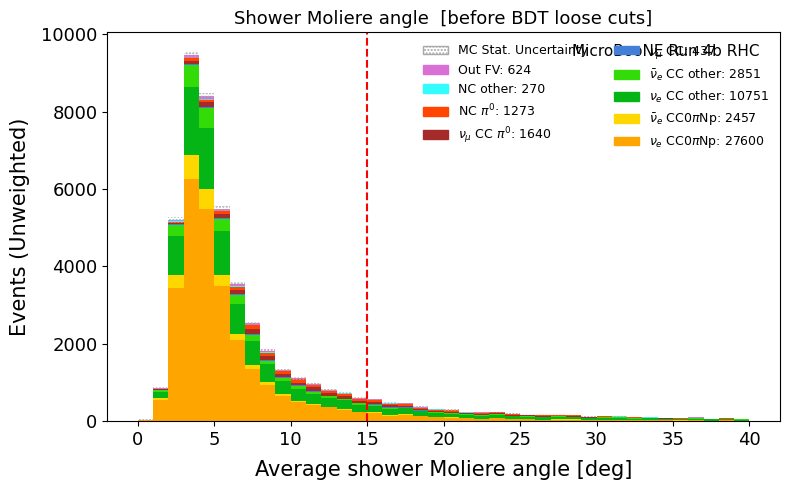

Saved diag_tksh_distance.pdf


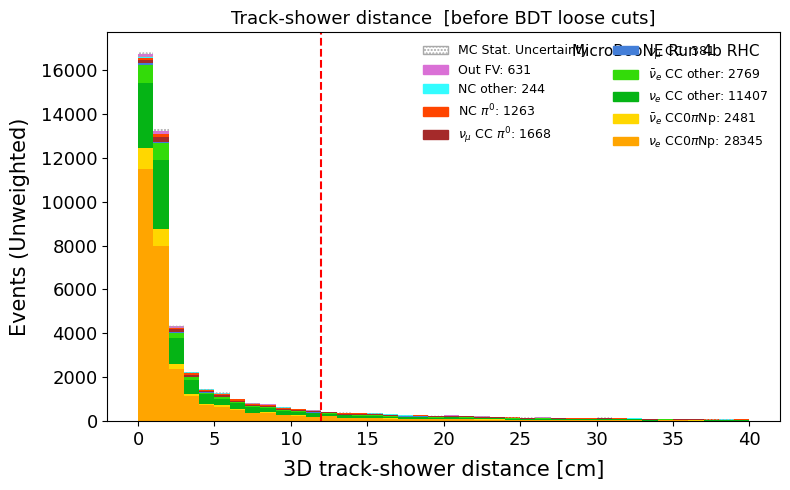

In [19]:
# ============================================================
# DIAGNOSTIC PLOTS: trksemlbl, shrmoliereavg, tksh_distance
# ============================================================
# NuGraph semantic label integers:
#   0 = MIP (min. ionising track)
#   1 = HIP (highly ionising = proton)  <- cut keeps only this
#   2 = shower
#   3 = Michel electron
#   4 = diffuse / other
#
# All three variables are cut on inside pandora_pass_bdt_loose,
# so we gate on events that passed quality + signal definition.

df_pre = before_cut(diag_df, 'pandora_pass_bdt_loose')
print(f'Events entering BDT loose block: {len(df_pre):,}')

# --- shrmoliereavg ---
plot_diag(
    df_pre, 'var_pandora_shrmoliereavg',
    bins=np.linspace(0, 40, 41),
    xlabel='Average shower Moliere angle [deg]',
    title='Shower Moliere angle  [before BDT loose cuts]',
    cut_line=15.0,
    savename='diag_shrmoliereavg.pdf',
)

# --- tksh_distance ---
plot_diag(
    df_pre, 'var_pandora_tksh_distance',
    bins=np.linspace(0, 40, 41),
    xlabel='3D track-shower distance [cm]',
    title='Track-shower distance  [before BDT loose cuts]',
    cut_line=12.0,
    savename='diag_tksh_distance.pdf',
)


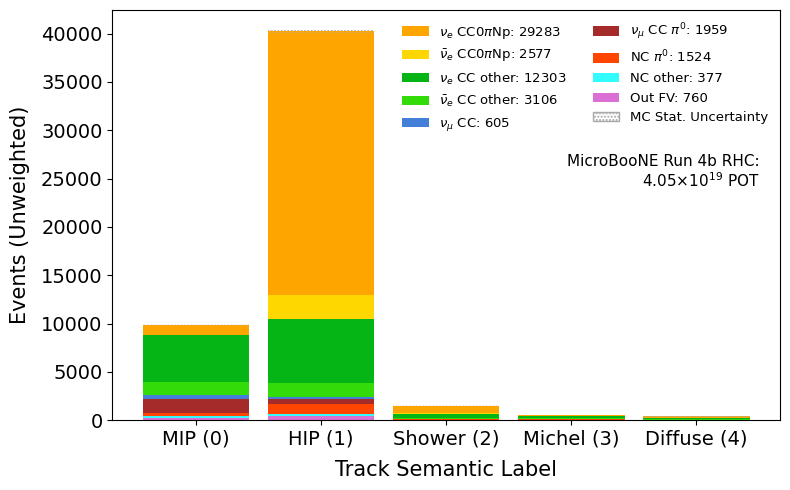

In [20]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cat_strings = [c[0] for c in CATEGORIES]
bins = np.arange(-0.5, 5.5, 1.0)
bin_centres = np.arange(5)
bar_width = 0.85

counts    = {cat: np.zeros(5) for cat in cat_strings}
counts_sq = {cat: np.zeros(5) for cat in cat_strings}

for root_path, file_type, beam_mode in entries:
    if file_type == 'extBNB':
        continue
    try:
        with uproot.open(root_path) as f:
            tree = f[TREE_NAME]
            pre  = tree['pandora_pass_pre'].array(library='np').astype(bool)
            vals = tree['var_pandora_trksemlbl'].array(library='np')
            cats = tree[BRANCH_CATEGORY].array(library='np')
            mask = pre & (vals < 9000)
            vals_sel = vals[mask]
            cats_sel = cats[mask]
            for cat in cat_strings:
                h, _ = np.histogram(vals_sel[cats_sel == cat], bins=bins)
                counts[cat]    += h
                counts_sq[cat] += h
    except Exception as e:
        print(f'WARNING: {root_path}: {e}')

fig, ax = plt.subplots(figsize=(8, 5))

# ── legend entries (forward order, with counts) ──
legend_handles = []
for cat_str, label, color in CATEGORIES:
    if counts[cat_str].sum() == 0:
        continue
    legend_handles.append(
        mpatches.Patch(facecolor=color, label=f'{label}: {int(counts[cat_str].sum())}')
    )

# ── stacked bars (reversed so signal on top) ──
bottom = np.zeros(5)
for cat_str, label, color in reversed(CATEGORIES):
    c = counts[cat_str]
    if c.sum() == 0:
        continue
    ax.bar(bin_centres, c, width=bar_width, bottom=bottom,
           color=color, edgecolor='none', align='center')
    bottom += c

total = bottom.copy()

# ── stat uncertainty band ──
total_err = np.sqrt(sum(counts_sq[cat] for cat in cat_strings))
ax.bar(bin_centres, 2 * total_err, width=bar_width,
       bottom=total - total_err, color='none', edgecolor='darkgray',
       hatch='.....', linewidth=0, align='center')
legend_handles.append(mpatches.Patch(
    facecolor='none', edgecolor='darkgray',
    hatch='.....', label='MC Stat. Uncertainty'))

# ── formatting ──
ax.set_xticks(range(5))
ax.set_xticklabels(
    ['MIP (0)', 'HIP (1)', 'Shower (2)', 'Michel (3)', 'Diffuse (4)'],
    fontsize=14)
ax.set_xlabel('Track Semantic Label', fontsize=15, labelpad=8)
ax.set_ylabel(Y_LABEL, fontsize=15, labelpad=8)
ax.tick_params(axis='both', labelsize=14)
ax.text(0.97, 0.56, f'{RUN_LABEL}:\n4.05×10$^{{19}}$ POT',
        transform=ax.transAxes, fontsize=11,
        verticalalignment='bottom', horizontalalignment='right')
ax.legend(handles=legend_handles, fontsize=9.5, ncol=2,
          loc='upper right', frameon=False)
plt.tight_layout()
plt.savefig('pandora_trksemlbl.pdf', transparent=False, bbox_inches='tight', dpi=300)
plt.show()